# Análise de séries temporais

## Entendendo o problema

Uma rede de restaurantes está com dificuldades em realizar o planejamento do negócio como um todo. A percepção é de que em alguns dias o movimento é muito baixo, fazendo com que os garçons fiquem muito ociosos. Em outros dias, o movimento é muito alto, e a quantidade de garçons parece ser insuficiente para atender a todas as pessoas.

Vamos realizar uma análise nos dados de **quantidade de clientes por dia nos restaurantes** para melhorar o planejamento de atendimento na rede de restaurantes.

### Fazendo a leitura dos dados

O primeiro passo é fazer a leitura da base de dados, a partir do arquivo `qtd_clientes_restaurantes.csv`. Vamos fazer a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) da biblioteca `pandas`.

In [1]:
import pandas as pd


In [3]:
dados = pd.read_csv('C:/Users/Thais Pereira/Documents/series_temporais/clientes_restaurantes.csv')

In [4]:
dados

,data,Chimi & Churri,Assa Frão
0,1/1/2016,65.0,139.0
1,1/2/2016,24.0,85.0
2,1/3/2016,24.0,81.0
3,1/4/2016,23.0,32.0
4,1/5/2016,2.0,43.0
...,...,...,...
473,4/18/2017,30.0,18.0
474,4/19/2017,20.0,18.0
475,4/20/2017,22.0,46.0
476,4/21/2017,38.0,38.0


O `DataFrame` apresenta informações de data e quantidade de clientes de dois restaurantes ao longo dos dias, o **Chimi & Churri** e o **Assa Frão**. Precisamos fazer uma análise desses dados de restaurante para aprimorar o planejamento da quantidade de garçons que precisam ser alocados em cada dia.

Vamos ver algumas informações adicionais dos dados, como presença de dados nulos e tipos de dados em cada coluna, usando o método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [5]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            478 non-null    str    
 1   Chimi & Churri  476 non-null    float64
 2   Assa Frão       477 non-null    float64
dtypes: float64(2), str(1)
memory usage: 11.3 KB


A coluna `data` é do tipo `object`, portanto está sendo entendida como um texto. Vamos aplicar uma transformação da coluna para o formato `datetime` e definir essa informação como o índice do `DataFrame`.

In [7]:
dados['data'] = pd.to_datetime(dados['data'])

dados.set_index('data', inplace = True)

In [8]:
dados

,Chimi & Churri,Assa Frão
data,,
2016-01-01,65.0,139.0
2016-01-02,24.0,85.0
2016-01-03,24.0,81.0
2016-01-04,23.0,32.0
2016-01-05,2.0,43.0
...,...,...
2017-04-18,30.0,18.0
2017-04-19,20.0,18.0
2017-04-20,22.0,46.0


A base de dados já está carregada e já possui os dados de data como sendo o índice do `DataFrame`.

### Encontrando dados nulos

In [11]:
dados['Chimi & Churri'][dados['Chimi & Churri'].isna()]

data
2016-04-05   NaN
2016-09-17   NaN
Name: Chimi & Churri, dtype: float64

Visualizando os nulos com um gráfico

In [12]:
import matplotlib.pyplot as plt

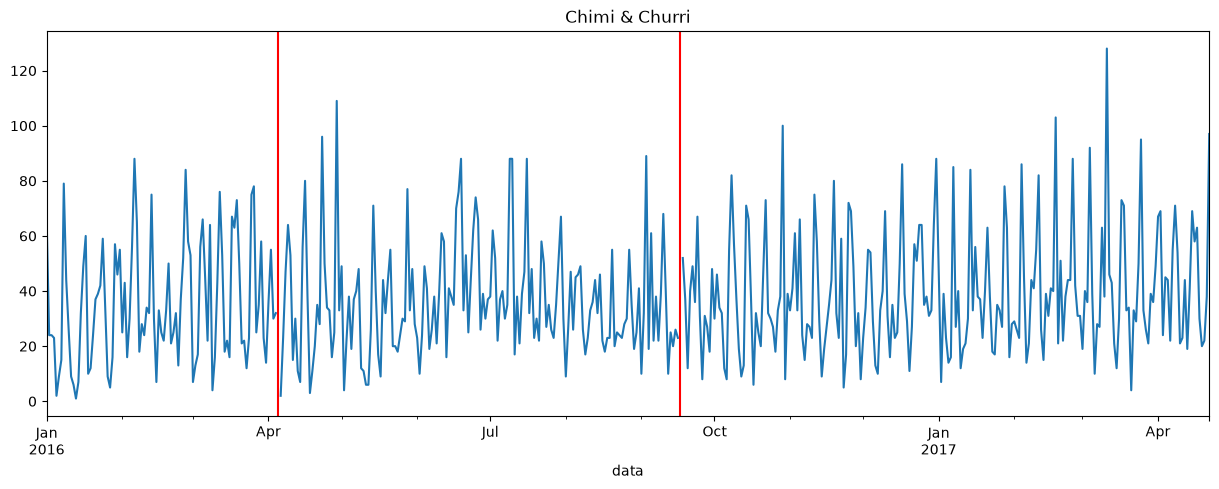

In [13]:
dados['Chimi & Churri'].plot(figsize = (15, 5), title = 'Chimi & Churri')
plt.axvline(x = dados['Chimi & Churri'][dados['Chimi & Churri'].isna()].index[0], color = 'red')
plt.axvline(x = dados['Chimi & Churri'][dados['Chimi & Churri'].isna()].index[1], color = 'red');

In [14]:
dados['Assa Frão'][dados['Assa Frão'].isna()]

data
2016-11-24   NaN
Name: Assa Frão, dtype: float64

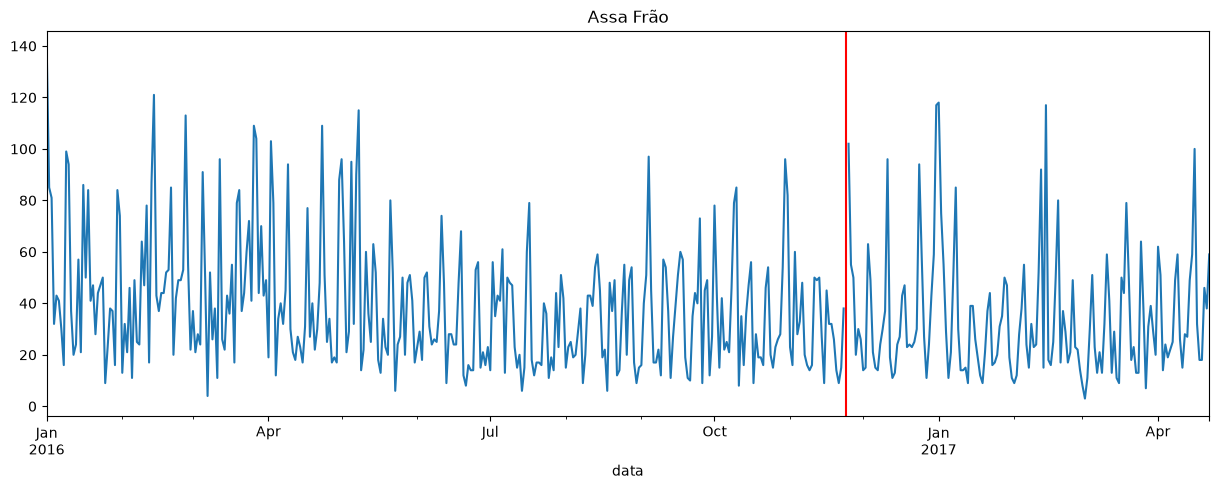

In [16]:
dados['Assa Frão'].plot(figsize = (15, 5), title = 'Assa Frão')
plt.axvline(x = dados['Assa Frão'][dados['Assa Frão'].isna()].index[0], color = 'red')

### Tratando dados nulos

Em séries temporais algumas opções são: 

1. preencher com o valor anterior
2. preencher com o valor posterior
3. preencher com o ponto médio do valor anterior e posterior

In [ ]:
# Vamos usar a opção 3: preencher com o ponto médio do valor anterior e posterior
# Método interpolate para preencher os valores nulos com base nos valores vizinhos

dados = dados.interpolate()

In [19]:
# verificando se funcionou, se não houver mais valores nulos, o método funcionou corretamente

dados.loc['2016-04-04':'2016-04-06']

,Chimi & Churri,Assa Frão
data,,
2016-04-04,32.0,12.0
2016-04-05,17.0,34.0
2016-04-06,2.0,40.0


In [20]:
dados.loc['2016-09-16':'2016-09-18']

,Chimi & Churri,Assa Frão
data,,
2016-09-16,23.0,51.0
2016-09-17,37.5,60.0
2016-09-18,52.0,57.0


In [21]:
dados.loc['2016-11-23':'2016-11-25']

,Chimi & Churri,Assa Frão
data,,
2016-11-23,5.0,38.0
2016-11-24,17.0,70.0
2016-11-25,72.0,102.0


### Explorando os dados

Visualizando a distribuição com histograma, bloxplot e describe

In [ ]:
# Os dos estão como decimais mas queremos que eles sejam inteiros, então vamos converter para int

dados = dados.astype(int)
dados

,Chimi & Churri,Assa Frão
data,,
2016-01-01,65,139
2016-01-02,24,85
2016-01-03,24,81
2016-01-04,23,32
2016-01-05,2,43
...,...,...
2017-04-18,30,18
2017-04-19,20,18
2017-04-20,22,46


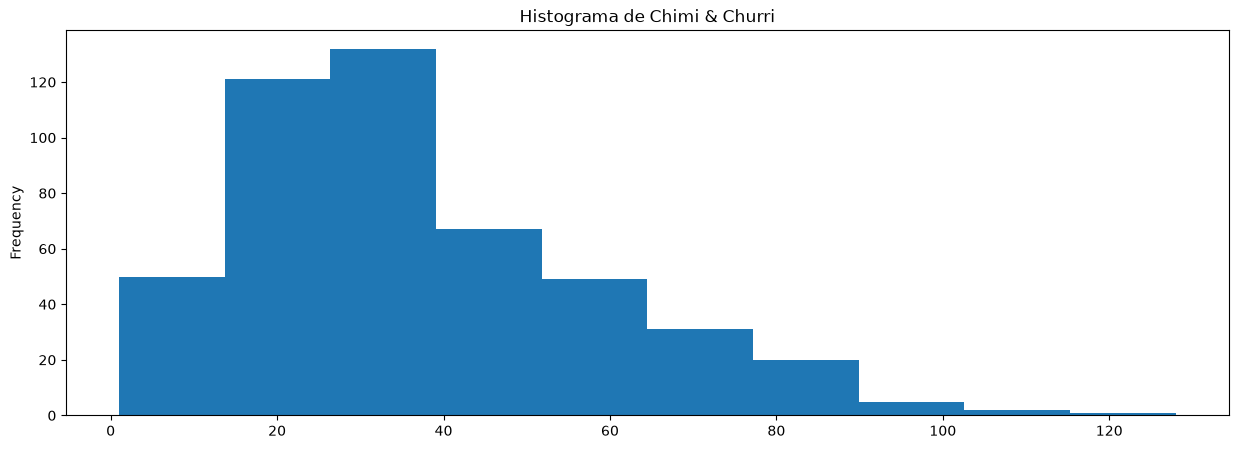

In [24]:
dados['Chimi & Churri'].plot(kind = 'hist', title = 'Histograma de Chimi & Churri', figsize = (15, 5)); 

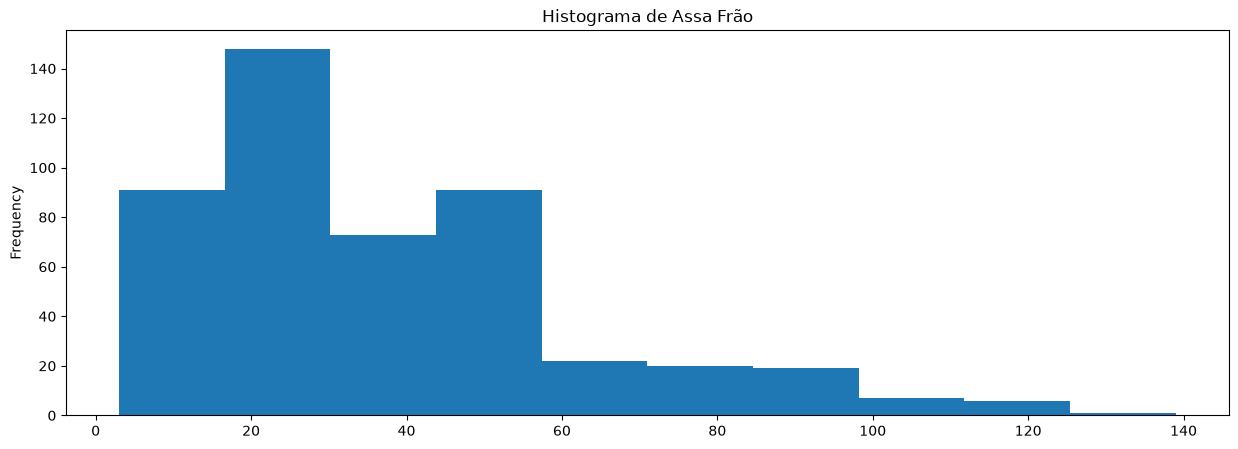

In [25]:
dados['Assa Frão'].plot(kind = 'hist', title = 'Histograma de Assa Frão', figsize = (15, 5)); 

In [27]:
dados.describe()

,Chimi & Churri,Assa Frão
count,478.000000,478.000000
mean,37.451883,37.679916
std,21.433061,24.619708
min,1.000000,3.000000
25%,22.250000,19.000000
50%,33.000000,30.500000
75%,49.000000,50.000000
max,128.000000,139.000000


<Axes: title={'center': 'Bloxplots da quantidade de clientes por restaurante'}>

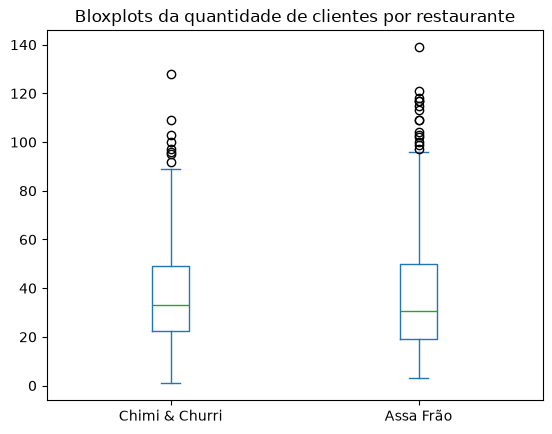

In [ ]:
dados.plot(kind = 'box', title = 'Boxplots da quantidade de clientes por restaurante')